In [1]:
import re
import pandas as pd
from pathlib import Path

def parse_dal_txt(path: str | Path):
    path = Path(path)
    model_tag = path.stem

    runs = []
    current = {}

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            # Run marker
            m = re.match(r"Run (\d+)", line)
            if m:
                if current:
                    runs.append(current)
                current = {
                    "model_tag": model_tag,
                    "run": int(m.group(1))
                }

            # Metrics
            for key, col in [
                ("DNN_DaL MRE", "MRE"),
                ("DNN_DaL MAE", "MAE"),
                ("DNN_DaL RMSE", "RMSE"),
                ("DNN_DaL R2", "R2"),
                ("DNN_DaL_time", "time_min"),
                ("Best shot rate", "best_shot_rate"),
            ]:
                if key in line:
                    val = float(re.findall(r"[-+]?[0-9]*\.?[0-9]+", line)[0])
                    current[col] = val

        if current:
            runs.append(current)

    return pd.DataFrame(runs)


In [2]:
from pathlib import Path

# directory where your txt files live
BASE_DIR = Path(".")   # use "." if same folder as notebook

data_txt_files = sorted(
    p for p in BASE_DIR.glob("*.txt")
    if p.name.startswith("data_")
)

data_txt_files


[PosixPath('data_EleutherAI_gpt-neox-20b_Target_throughput_tokens_per_sec_800_0-30_01-16_09-18-26.txt'),
 PosixPath('data_Salesforce_codegen2-16B_Target_throughput_tokens_per_sec_800_0-30_01-16_08-07-33.txt'),
 PosixPath('data_bigcode_starcoder_Target_throughput_tokens_per_sec_800_0-30_01-15_23-27-00.txt'),
 PosixPath('data_bigscience_mt0-xxl_Target_throughput_tokens_per_sec_800_0-30_01-15_22-09-26.txt'),
 PosixPath('data_google_flan-t5-xl_Target_throughput_tokens_per_sec_800_0-30_01-15_07-58-49.txt'),
 PosixPath('data_google_flan-t5-xxl_Target_throughput_tokens_per_sec_800_0-30_01-15_02-07-12.txt'),
 PosixPath('data_google_flan-ul2_Target_throughput_tokens_per_sec_800_0-30_01-14_23-27-15.txt'),
 PosixPath('data_ibm_mpt-7b-instruct2_Target_throughput_tokens_per_sec_800_0-30_01-14_21-57-23.txt'),
 PosixPath('data_llama-13b_Target_throughput_tokens_per_sec_800_0-30_01-14_16-43-22.txt'),
 PosixPath('data_llama-7b_Target_throughput_tokens_per_sec_800_0-30_01-14_09-37-57.txt')]

In [3]:
import re

def parse_filename_meta(path: Path):
    name = path.stem
    parts = name.split("_Target_")

    model = parts[0].replace("data_", "")
    target = parts[1].split("_")[0]

    return {
        "file": path.name,
        "model_tag": model,
        "target": target
    }

meta_df = pd.DataFrame(parse_filename_meta(p) for p in data_txt_files)
meta_df


,file,model_tag,target
0,data_EleutherAI_gpt-neox-20b_Target_throughput...,EleutherAI_gpt-neox-20b,throughput
1,data_Salesforce_codegen2-16B_Target_throughput...,Salesforce_codegen2-16B,throughput
2,data_bigcode_starcoder_Target_throughput_token...,bigcode_starcoder,throughput
3,data_bigscience_mt0-xxl_Target_throughput_toke...,bigscience_mt0-xxl,throughput
4,data_google_flan-t5-xl_Target_throughput_token...,google_flan-t5-xl,throughput
5,data_google_flan-t5-xxl_Target_throughput_toke...,google_flan-t5-xxl,throughput
6,data_google_flan-ul2_Target_throughput_tokens_...,google_flan-ul2,throughput
7,data_ibm_mpt-7b-instruct2_Target_throughput_to...,ibm_mpt-7b-instruct2,throughput
8,data_llama-13b_Target_throughput_tokens_per_se...,llama-13b,throughput
9,data_llama-7b_Target_throughput_tokens_per_sec...,llama-7b,throughput


In [4]:
from pathlib import Path

BASE_DIR = Path(".")  # same folder as this notebook
txt_files = sorted([p for p in BASE_DIR.glob("*.txt") if p.name.startswith("data_")])

print("Found files:", len(txt_files))
txt_files[:5]


Found files: 10


[PosixPath('data_EleutherAI_gpt-neox-20b_Target_throughput_tokens_per_sec_800_0-30_01-16_09-18-26.txt'),
 PosixPath('data_Salesforce_codegen2-16B_Target_throughput_tokens_per_sec_800_0-30_01-16_08-07-33.txt'),
 PosixPath('data_bigcode_starcoder_Target_throughput_tokens_per_sec_800_0-30_01-15_23-27-00.txt'),
 PosixPath('data_bigscience_mt0-xxl_Target_throughput_tokens_per_sec_800_0-30_01-15_22-09-26.txt'),
 PosixPath('data_google_flan-t5-xl_Target_throughput_tokens_per_sec_800_0-30_01-15_07-58-49.txt')]

In [5]:
import pandas as pd

def split_model_target_from_name(name: str):
    stem = name[:-4] if name.endswith(".txt") else name
    if "_Target_" not in stem:
        return ("unknown", "unknown")
    left, right = stem.split("_Target_", 1)
    model = left.replace("data_", "")
    target = right.split("_", 1)[0]
    return (model, target)

meta_df = pd.DataFrame({"file": [p.name for p in txt_files]})
meta_df[["model_tag", "target"]] = meta_df["file"].apply(lambda x: pd.Series(split_model_target_from_name(x)))

meta_df.head()


,file,model_tag,target
0,data_EleutherAI_gpt-neox-20b_Target_throughput...,EleutherAI_gpt-neox-20b,throughput
1,data_Salesforce_codegen2-16B_Target_throughput...,Salesforce_codegen2-16B,throughput
2,data_bigcode_starcoder_Target_throughput_token...,bigcode_starcoder,throughput
3,data_bigscience_mt0-xxl_Target_throughput_toke...,bigscience_mt0-xxl,throughput
4,data_google_flan-t5-xl_Target_throughput_token...,google_flan-t5-xl,throughput


In [6]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

RUN_PATTERNS = [
    re.compile(r"^\s*Run\s+(\d+)\s*:?\s*$", re.IGNORECASE),
    re.compile(r"^\s*Run\s+(\d+)\s*:", re.IGNORECASE),
    re.compile(r"^\s*-+\s*Run\s+(\d+)\s*-+\s*$", re.IGNORECASE),
]

METRIC_PATTERNS = [
    (re.compile(r"\bDNN_DaL\b.*\bR2\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), "R2"),
    (re.compile(r"\bDNN_DaL\b.*\bMAE\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), "MAE"),
    (re.compile(r"\bDNN_DaL\b.*\bRMSE\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), "RMSE"),
    (re.compile(r"\bDNN_DaL\b.*\bMRE\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*%?"), "MRE"),
    (re.compile(r"\bTime cost \(minutes\)\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), "time_min"),
    (re.compile(r"\bDNN_DaL_time \(minutes\)\b\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), "time_min"),
]

def parse_dal_txt_file(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    rows = []
    current = None

    def flush():
        nonlocal current
        if current is not None:
            rows.append(current)
            current = None

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()

            # detect Run header
            run_id = None
            for rp in RUN_PATTERNS:
                m = rp.match(s)
                if m:
                    run_id = int(m.group(1))
                    break

            if run_id is not None:
                flush()
                current = {"file": path.name, "run": run_id}
                continue

            if current is None:
                continue

            # detect metrics
            for pat, col in METRIC_PATTERNS:
                mm = pat.search(s)
                if mm:
                    try:
                        current[col] = float(mm.group(1))
                    except:
                        pass

    flush()
    return pd.DataFrame(rows)

# Parse all files
runs_df = pd.concat([parse_dal_txt_file(p) for p in txt_files], ignore_index=True)

runs_df.shape, runs_df.head()


((300, 6),
                                                 file  run         MRE  \
 0  data_EleutherAI_gpt-neox-20b_Target_throughput...    1  612.538900   
 1  data_EleutherAI_gpt-neox-20b_Target_throughput...    2  442.083893   
 2  data_EleutherAI_gpt-neox-20b_Target_throughput...    3  428.399647   
 3  data_EleutherAI_gpt-neox-20b_Target_throughput...    4         NaN   
 4  data_EleutherAI_gpt-neox-20b_Target_throughput...    5  414.564708   
 
           MAE        RMSE        R2  
 0  222.984192  531.309569  0.188587  
 1  198.162107  540.174270  0.167244  
 2  205.115567  539.379949  0.168684  
 3         NaN         NaN       NaN  
 4  193.918720  540.849556  0.164577  )

In [7]:
# show first 80 lines of the first txt file
p0 = txt_files[0]
print(p0.name)
print("------")
print("\n".join(p0.read_text(errors="ignore").splitlines()[:80]))


data_EleutherAI_gpt-neox-20b_Target_throughput_tokens_per_sec_800_0-30_01-16_09-18-26.txt
------
N_train=800 N_test=88919 min_samples=2
Run 1
depth1 N_samples of 2 divisions: 787 13
depth1 DNN_DaL MRE: 612.5389002694418
depth1 DNN_DaL MAE: 222.98419184337558
depth1 DNN_DaL RMSE: 531.3095692142969
depth1 DNN_DaL R2: 0.18858688353694175
depth1 DNN_DaL_time (minutes): 7.8807666301727295
Best shot rate: 0.98
Run 2
depth1 N_samples of 2 divisions: 708 92
depth1 DNN_DaL MRE: 442.0838928184685
depth1 DNN_DaL MAE: 198.16210734494135
depth1 DNN_DaL RMSE: 540.1742699206127
depth1 DNN_DaL R2: 0.16724358469540768
depth1 DNN_DaL_time (minutes): 7.902489348252614
Best shot rate: 0.89
Run 3
depth1 N_samples of 2 divisions: 732 68
depth1 DNN_DaL MRE: 428.3996468495617
depth1 DNN_DaL MAE: 205.11556743008975
depth1 DNN_DaL RMSE: 539.3799492942542
depth1 DNN_DaL R2: 0.16868361208172755
depth1 DNN_DaL_time (minutes): 8.01386839946111
Best shot rate: 0.90
Run 4
depth1 N_samples of 1 divisions: 800
Run 5
de

In [8]:
runs_df2 = runs_df.merge(meta_df[["file", "model_tag", "target"]], on="file", how="left")
runs_df2.head()


,file,run,MRE,MAE,RMSE,R2,model_tag,target
0,data_EleutherAI_gpt-neox-20b_Target_throughput...,1,612.538900,222.984192,531.309569,0.188587,EleutherAI_gpt-neox-20b,throughput
1,data_EleutherAI_gpt-neox-20b_Target_throughput...,2,442.083893,198.162107,540.174270,0.167244,EleutherAI_gpt-neox-20b,throughput
2,data_EleutherAI_gpt-neox-20b_Target_throughput...,3,428.399647,205.115567,539.379949,0.168684,EleutherAI_gpt-neox-20b,throughput
3,data_EleutherAI_gpt-neox-20b_Target_throughput...,4,NaN,NaN,NaN,NaN,EleutherAI_gpt-neox-20b,throughput
4,data_EleutherAI_gpt-neox-20b_Target_throughput...,5,414.564708,193.918720,540.849556,0.164577,EleutherAI_gpt-neox-20b,throughput


In [19]:
metrics = ["R2", "MAE", "RMSE", "MRE"]
table_mean_std = (
    runs_df2
    .groupby(["model_tag", "target"])[metrics]
    .agg(["mean", "std"])
    .round(4)
)

table_mean_std

# Save to CSV
output_csv = "dal_results_summary.csv"
table_mean_std.to_csv(output_csv)
print(f"Saved summary to {output_csv}")


Saved summary to dal_results_summary.csv


In [20]:
table_mean_std.columns = [f"{m}_{stat}" for m, stat in table_mean_std.columns]
table_mean_std = table_mean_std.reset_index()
table_mean_std.head()


,model_tag,target,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MRE_mean,MRE_std
0,EleutherAI_gpt-neox-20b,throughput,0.1739,0.0542,211.0501,12.2912,536.4741,16.7425,511.4232,74.8281
1,Salesforce_codegen2-16B,throughput,0.1312,0.0479,143.1969,12.3053,383.6094,11.6910,880.8690,274.0020
2,bigcode_starcoder,throughput,0.1291,0.1828,223.9874,20.4695,574.8594,50.9156,341.0549,47.8269
3,bigscience_mt0-xxl,throughput,0.1058,0.0557,221.3983,12.8465,502.5314,11.8440,538.1292,133.3388
4,google_flan-t5-xl,throughput,0.1350,0.0335,154.2757,11.2995,405.1481,7.3312,585.4424,105.7683


In [21]:
table_mean_std.to_csv("dal_results_summary_flat.csv", index=False)

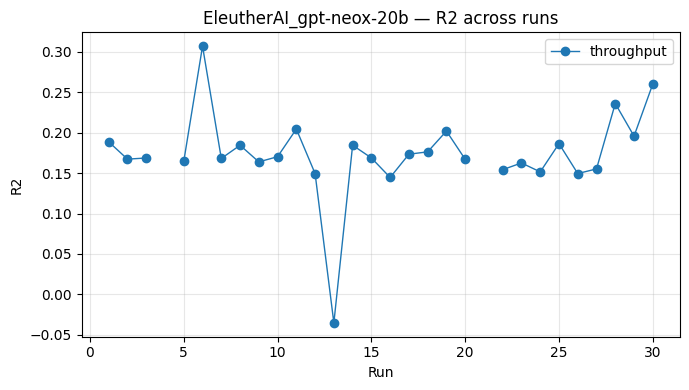

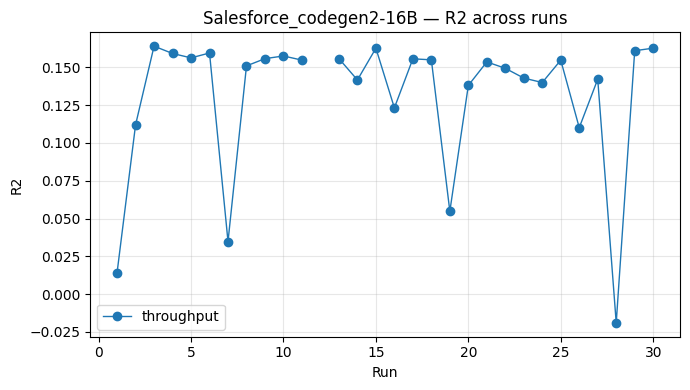

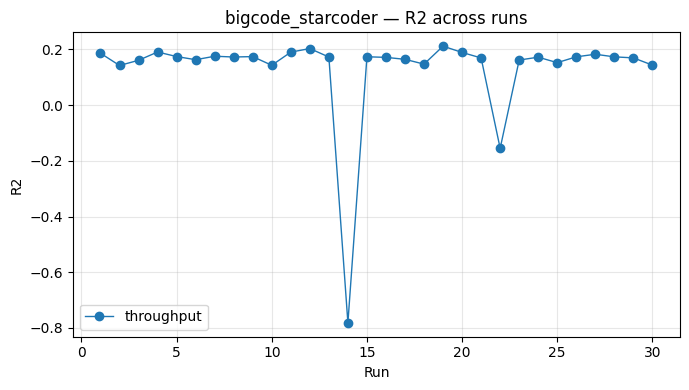

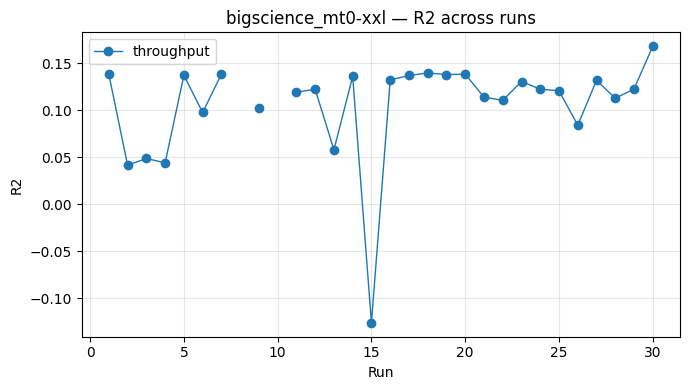

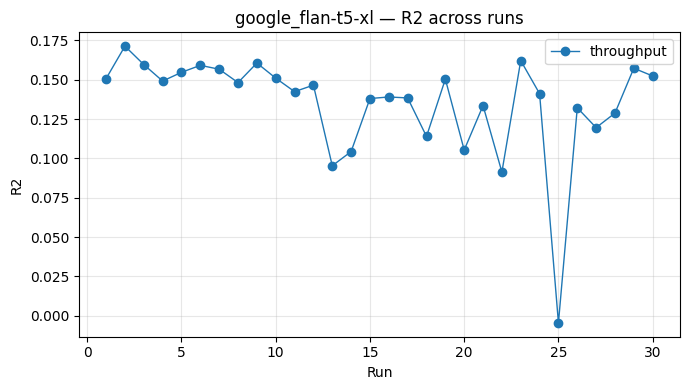

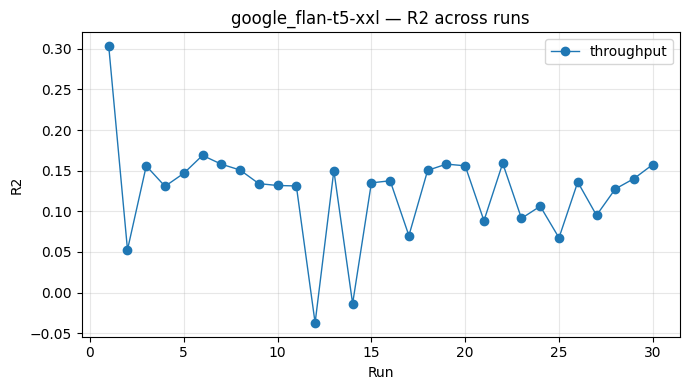

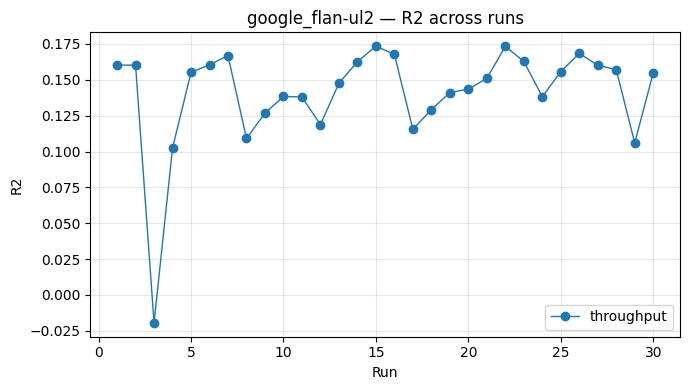

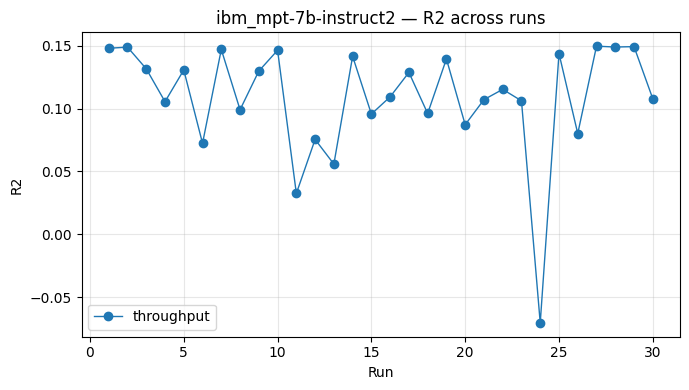

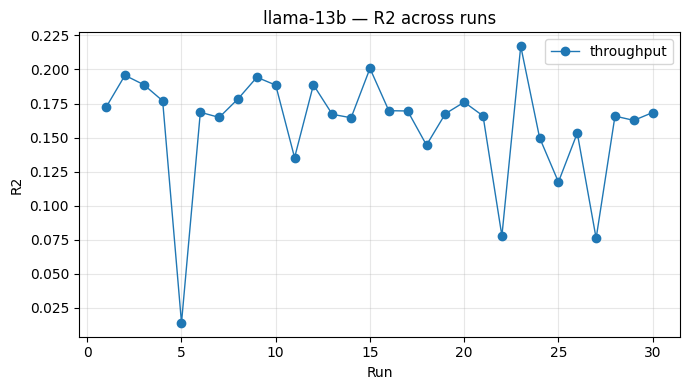

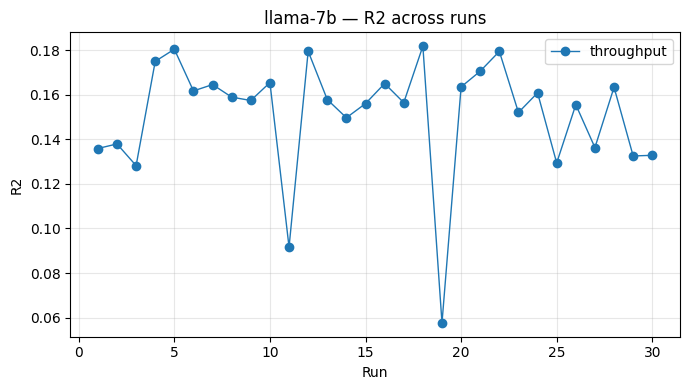

In [12]:
import matplotlib.pyplot as plt

def plot_runs_per_model(df, metric="R2"):
    for model, g_model in df.groupby("model_tag"):
        plt.figure(figsize=(7, 4))
        for target, g in g_model.groupby("target"):
            g = g.sort_values("run")
            if metric in g.columns:
                plt.plot(g["run"], g[metric], marker="o", linewidth=1, label=target)

        plt.title(f"{model} — {metric} across runs")
        plt.xlabel("Run")
        plt.ylabel(metric)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_runs_per_model(runs_df2, metric="R2")


In [14]:
TARGET = "throughput"   # change if needed
dfp = runs_df2[runs_df2["target"] == TARGET].copy()
dfp.shape


(300, 8)

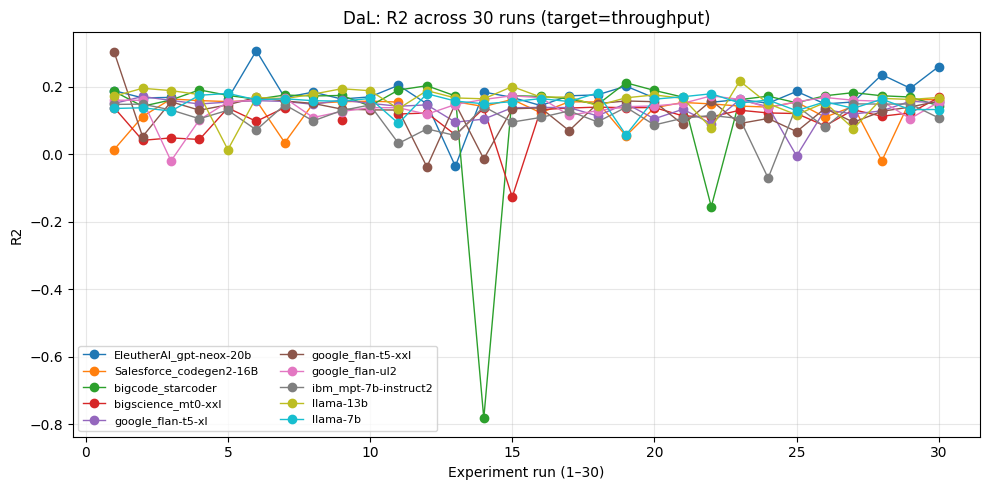

In [15]:
import matplotlib.pyplot as plt

# Build wide table: index=run, columns=model_tag, values=R2
r2_wide = (
    dfp.pivot_table(index="run", columns="model_tag", values="R2", aggfunc="mean")
    .sort_index()
)

plt.figure(figsize=(10, 5))
for col in r2_wide.columns:
    plt.plot(r2_wide.index, r2_wide[col], marker="o", linewidth=1, label=col)

plt.xlabel("Experiment run (1–30)")
plt.ylabel("R2")
plt.title(f"DaL: R2 across 30 runs (target={TARGET})")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


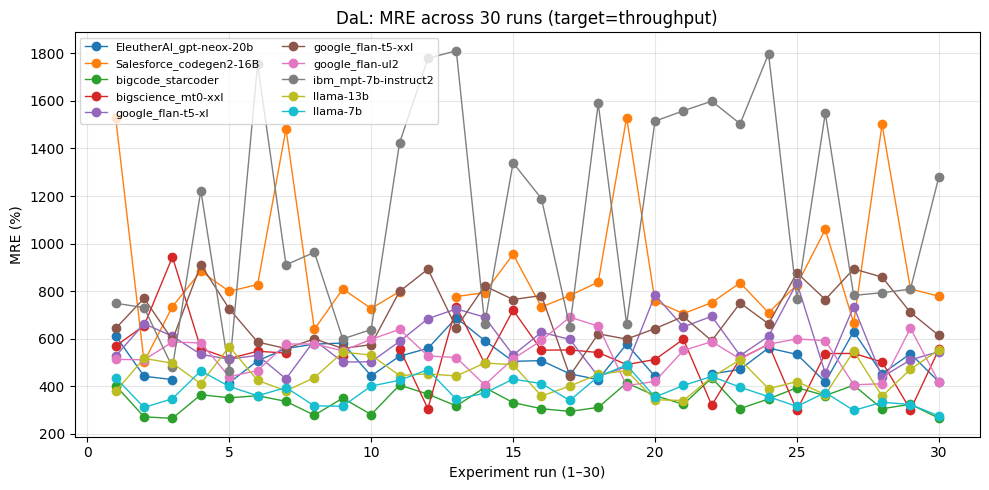

In [16]:
mre_wide = (
    dfp.pivot_table(index="run", columns="model_tag", values="MRE", aggfunc="mean")
    .sort_index()
)

plt.figure(figsize=(10, 5))
for col in mre_wide.columns:
    plt.plot(mre_wide.index, mre_wide[col], marker="o", linewidth=1, label=col)

plt.xlabel("Experiment run (1–30)")
plt.ylabel("MRE (%)")
plt.title(f"DaL: MRE across 30 runs (target={TARGET})")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()
